# Asignación de Polos — Diseño de Controladores

Este notebook muestra cómo usar la función `asigne_polos` para diseñar un controlador
por asignación de polos mediante la **matriz de Sylvester**, y visualizar los resultados.

**Esquema de control (realimentación unitaria):**

```
  r ──►(+)──► C(s) ──► G(s) ──► y
        ▲ −                │
        └──────────────────┘
```


In [1]:
!pip install control
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

!rm -f ubicarpolos.py && wget -O ubicarpolos.py https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/ubicarpolos.py
from ubicarpolos import asigne_polos

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
    'font.size': 11,
})


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 8.8 MB/s eta 0:00:00
--2026-04-22 13:19:21--  https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/ubicarpolos.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3249 (3.2K) [text/plain]
Saving to: ‘ubicarpolos.py’

ubicarpolos.py      100%[===================>]   3.17K  --.-KB/s    in 0s      

2026-04-22 13:19:21 (36.5 MB/s) - ‘ubicarpolos.py’ saved [3249/3249]



## 1. Definimos la planta



$$G(s) = \frac{2}{s^3 + 6s^2 + 11s + 6} = \frac{2}{(s+1)(s+2)(s+3)}$$

Polos deseados: $\{-8,\; -9, \; -10\; -2 \pm 2j\}$ (5 polos → controlador mínimo de orden 2).


In [10]:
G=ctrl.tf([1.15, 0.17], [1, 0.73, 0.92, 0])
print("Planta P(s):")
print(G)
print(f"Polos: {ctrl.poles(G)}")


Planta P(s):
<TransferFunction>: sys[29]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       1.15 s + 0.17
  -----------------------
  s^3 + 0.73 s^2 + 0.92 s
Polos: [-0.365+0.88700338j -0.365-0.88700338j  0.   +0.j        ]


## 2. Elegir los polos deseados

Para una planta de orden $n = 3$, necesitamos al menos $2n - 1 = 5$ polos para un controlador de orden minimo. Por ejemplo:
$$s_1 = -10 , s_2= -9, s_3=-8,  \quad s_{4,5} = -2 \pm 2j$$


In [22]:
polos_deseados = [-.5, -.41, -.41, -.5+.1j, -.5-.1j]

print(f"Polos deseados: {polos_deseados}")


Polos deseados: [-0.5, -0.41, -0.41, (-0.5+0.1j), (-0.5-0.1j)]


## 3. Diseñar el controlador

In [23]:
C, T, Gur, S, err = asigne_polos(G, polos_deseados)

print("Controlador C(s):")
print(C)
print()
print("Lazo cerrado T(s):")
print(T)
print(f"\nPolos obtenidos: {np.round(ctrl.poles(T), 4)}")


0 states have been removed from the model
1 states have been removed from the model
0 states have been removed from the model
Controlador C(s):
<TransferFunction>: sys[83]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -0.09519 s^2 - 0.5023 s + 0.1285
  --------------------------------
       s^2 + 1.59 s + 0.1869

Lazo cerrado T(s):
<TransferFunction>: sys[87]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        -0.1095 s^3 - 0.5939 s^2 + 0.06243 s + 0.02185
  -----------------------------------------------------------
  s^5 + 2.32 s^4 + 2.158 s^3 + 1.005 s^2 + 0.2344 s + 0.02185

Polos obtenidos: [-0.5 +0.1j -0.5 -0.1j -0.5 +0.j  -0.41+0.j  -0.41-0.j ]


## 4. Respuesta al escalón

Obtenemos la respuesta en lazo cerrado del sistema.


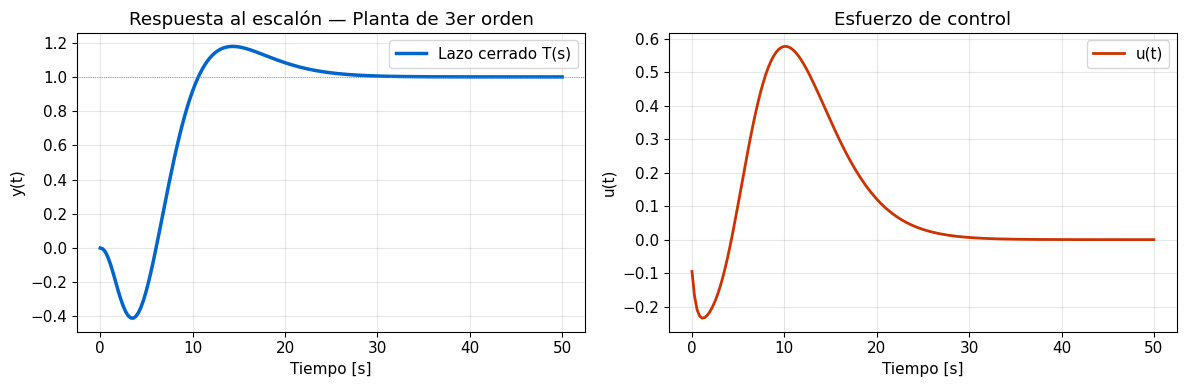

In [26]:
# respuesta al escalón
t_cl, y_cl = ctrl.step_response(T,50)



fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t_u, y_u = ctrl.step_response(Gur, t_cl)

ax = axes[0]
ax.plot(t_cl, y_cl, "-",  color="#0066cc", lw=2.5, label="Lazo cerrado T(s)")
ax.axhline(1, color="gray", lw=0.6, ls=":")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("y(t)")
ax.set_title("Respuesta al escalón — Planta de 3er orden")
ax.legend()

ax = axes[1]
ax.plot(t_u, y_u, "-", color="#cc3300", lw=2, label="u(t)")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("u(t)")
ax.set_title("Esfuerzo de control")
ax.legend()
plt.tight_layout()
plt.show()


# Actividad: rediseñar los controladores para que la tengan:
- Error de posición cero
- Error de velocidad cero

